In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_excel('/content/crop yield data sheet.xlsx')
df.head(3)

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      100 non-null    object 
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), object(1)
memory usage: 6.1+ KB


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [6]:
print(df['Temperatue'].apply(type).unique())

df['Temperatue'] = df['Temperatue'].astype(str)

for column in ['Temperatue']:
    df[column] = le.fit_transform(df[column])

[<class 'int'> <class 'float'> <class 'str'>]


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      109 non-null    int64  
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 6.1 KB


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check missing values
print(df.isnull().sum())

Rain Fall (mm)    10
Fertilizer        10
Temperatue         0
Nitrogen (N)      10
Phosphorus (P)    10
Potassium (K)     10
Yeild (Q/acre)    10
dtype: int64


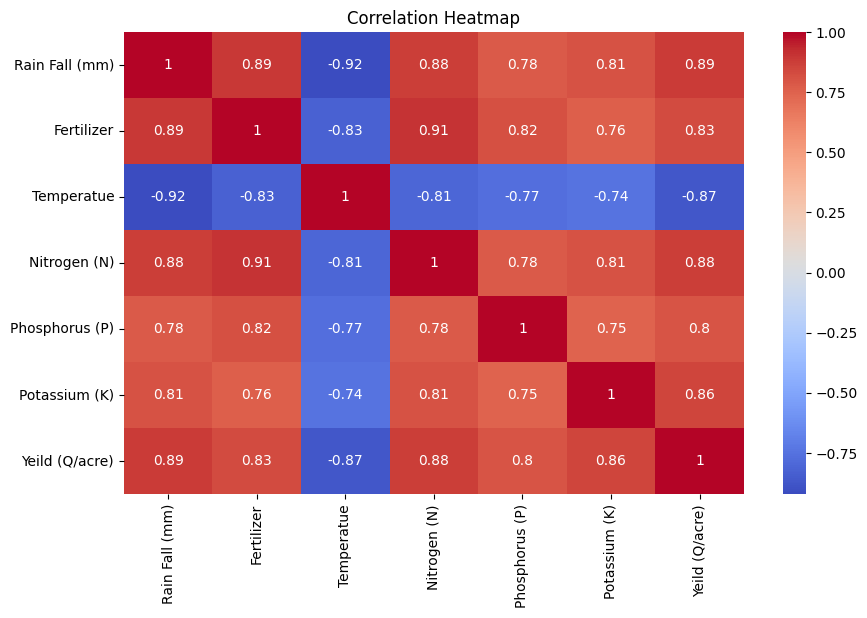

In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

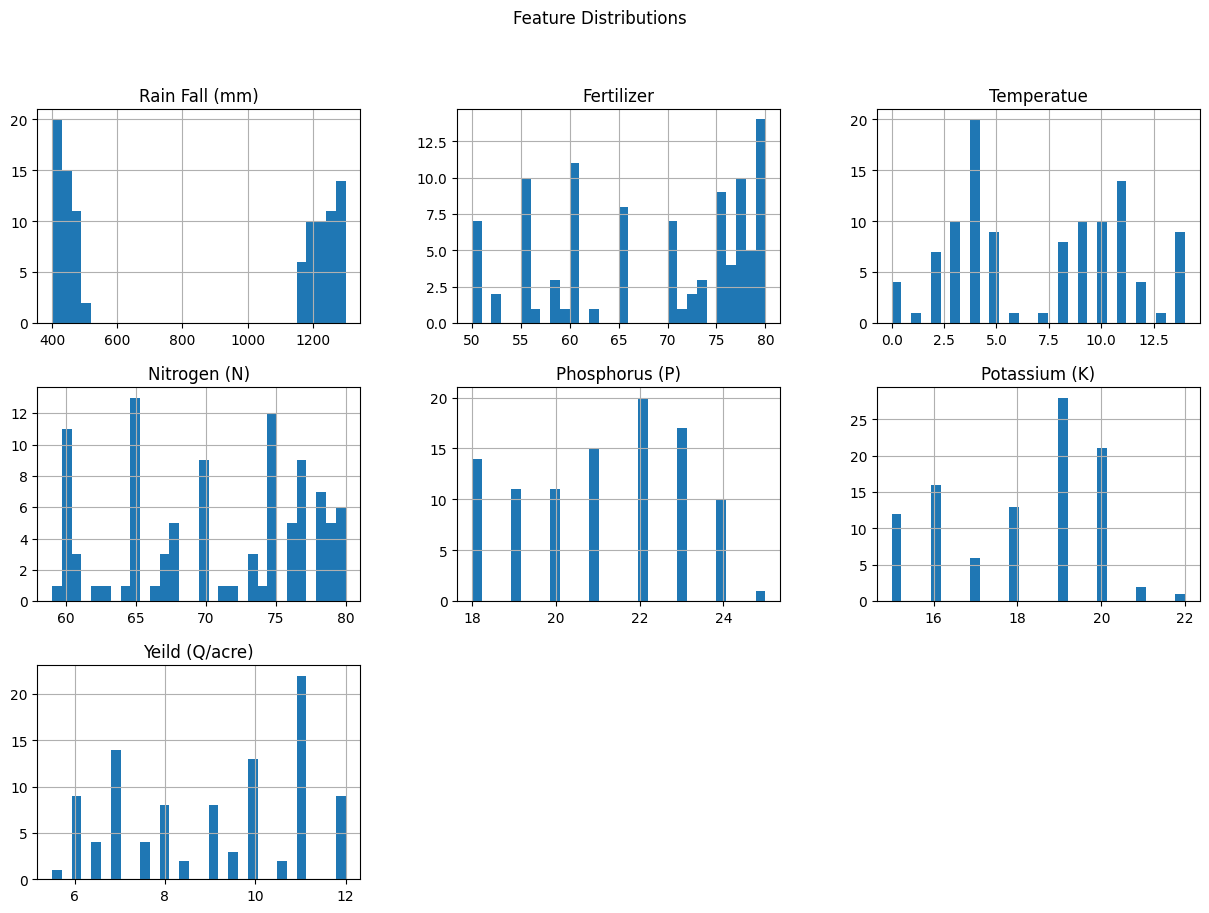

In [13]:
# Distribution plots
df.hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

In [19]:
df.isnull().sum()

,0
Rain Fall (mm),10
Fertilizer,10
Temperatue,0
Nitrogen (N),10
Phosphorus (P),10
Potassium (K),10
Yeild (Q/acre),10


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split features & targetX = df.drop(columns=['Yeild (Q/acre)'])
y = df['Yeild (Q/acre)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

y_train.fillna(y_train.mean(), inplace=True)
y_test.fillna(y_test.mean(), inplace=True)


# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions & Metrics
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 0.6626766566766567
RMSE: 0.7959623957211442
R² Score: 0.6536059946085324


In [20]:
import pickle

with open("crop_yield_model.pkl", "wb") as f:
    pickle.dump(model, f)
